# Notebook 05. External Evidence — 맥락과 교차확인

## 분석 질문

Triage와 선택적 재검토로 확인된 사례가 다른 외부자료에서도 같은 방향으로 설명되거나 확인되는가?

- <b>선행 단계</b> — `04_model_evolution_and_experiments.ipynb`에서 Triage와 선택적 ELECTRE/SMAA는 확인 순서를 정하지만 변화의 원인은 설명하지 못함을 확인했다.

## 입력

| 구분 | 경로 |
|---|---|
| 자료 역할 표 | `outputs/final_model/04_external_evidence/data_role_table.csv` |
| 외부근거 요약(최신분기) | `outputs/final_model/04_external_evidence/external_evidence_summary.csv` |
| 인계 근거(explanation trace) | `outputs/final_model/05_handoff/tables/explanation_trace.csv` |
| Triage 패널 | `outputs/final_model/02_triage/tables/triage_panel.csv` |
| EIS 검증 패널 | `data/processed/eis/eis_validation_panel.csv` |

## 출력

이 노트북은 새 표·그림 파일을 저장하지 않는다. 기존 산출물을 불러와 화면에서만 확인한다.

## 구성

| 파트 | 내용 | 성격 |
|---|---|---|
| 1 | 산출물 불러오기와 최신분기 일관성 확인 | 확증 |
| 2 | 데이터 가용성·역할 표 | 확증 |
| 3 | PPI — 명목 대 조정 생산 비교 | 확증 |
| 4 | EIS — 다른 모집단 고용 교차확인 | 확증 |
| 5 | 최신 우선점검 2건의 외부근거 | 확증 |
| 6 | 불일치·미확인의 처리 원칙 | 확증 |

## 전체 수행 흐름

```text
CORE
  ↓
Triage
  ↓ (추가확인일 때만)
Selective ELECTRE/SMAA
  ↓
External Evidence  ── 판정 변경 X / 맥락·원인후보·확인질문 보강 O
```

1. 자료 역할 표에서 "파일이 있다"와 "이번 판정 근거로 쓸 수 있다"를 구분한다.
2. PPI 조정 생산을 명목 생산과, EIS 고용을 KICOX 고용과 각각 나란히 비교한다.
3. 최신 우선점검 2건의 외부근거와 확인질문을 정리한다.
4. 외부자료가 Triage 단계를 자동으로 바꾸지 않는 이유를 밝힌다.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src').is_dir())
sys.path.insert(0, str(ROOT / 'src'))
from utils import notebook_config as config
from core.analysis.config import setup_matplotlib
setup_matplotlib()
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 120)

def _md_value(value):
    if pd.isna(value): return '—'
    if isinstance(value, (float, np.floating)): return f'{value:,.2f}'
    return str(value).replace('|', '\\|').replace('\n', ' / ')

def show_table(frame, max_rows=30):
    view=frame.head(max_rows)
    header='| '+' | '.join(map(str,view.columns))+' |'
    rule='| '+' | '.join(['---']*len(view.columns))+' |'
    rows=['| '+' | '.join(_md_value(v) for v in row)+' |' for row in view.itertuples(index=False,name=None)]
    note=f'\n\n*상위 {max_rows}행만 표시*' if len(frame)>max_rows else ''
    display(Markdown('\n'.join([header,rule,*rows])+note))

def show_records(frame, title_col, fields=None, max_rows=30):
    fields=fields or [c for c in frame.columns if c!=title_col]
    blocks=[]
    for _, row in frame.head(max_rows).iterrows():
        blocks.append('#### '+_md_value(row[title_col]))
        blocks.extend(f'- **{c}:** {_md_value(row[c])}' for c in fields)
    if len(frame)>max_rows: blocks.append(f'*상위 {max_rows}건만 표시*')
    display(Markdown('\n\n'.join(blocks)))

STAGE_ORDER = ['관찰', '추가확인', '우선점검', '자료확인']
STAGE_COLORS = {'관찰':'#7895A8', '추가확인':'#D39A2C', '우선점검':'#C5523F', '자료확인':'#777777'}
STATE_ORDER = ['S1', 'S2', 'S3', 'S4', 'N', 'INVALID']
STATE_COLORS = {'S1':'#4C78A8','S2':'#72B7B2','S3':'#F2CF5B','S4':'#B279A2','N':'#BDBDBD','INVALID':'#F2F2F2'}

## 1단계. 산출물 불러오기와 최신분기 일관성 확인

### 왜 이걸 보나

외부근거 표는 Triage·인계 산출물과 같은 최신분기, 같은 업종 구성을 가리켜야 한다. 먼저 이 네 산출물이 서로 어긋나지 않는지 확인한다.

In [2]:
roles=pd.read_csv(config.DATA_ROLE_PATH,encoding='utf-8-sig'); evidence=pd.read_csv(config.EVIDENCE_SUMMARY_PATH,encoding='utf-8-sig')
trace=pd.read_csv(config.HANDOFF_TRACE_PATH,encoding='utf-8-sig'); triage=pd.read_csv(config.TRIAGE_PANEL_PATH,encoding='utf-8-sig')
assert set(evidence.stage)==set(triage.loc[triage.quarter.eq(triage.quarter.max()),'stage']); assert trace.human_decision_required.astype(str).str.lower().eq('true').all()
print(f'현재 자료 역할 {len(roles)}종 | 최신 외부근거 {len(evidence)}개 업종 | latest={evidence.quarter.max()}')

현재 자료 역할 15종 | 최신 외부근거 10개 업종 | latest=2026Q2


### 관찰 결과

- 정리된 자료 역할은 15종(CORE 2, VALIDATION 2, CONTEXT 9, EXCLUDE 2)이고, 최신 외부근거는 10개 업종, 최신분기는 2026Q2다.
- 외부근거의 stage 구성은 Triage 최신분기 stage 구성과 같고, 인계 대상 10건은 모두 담당자 확인이 필요하다(human_decision_required = True).

> 주의: 이 확인은 산출물 간 정합성 점검이며, 각 자료가 판정 근거로 쓸 수 있는지는 다음 절에서 따로 본다.

## 2단계. 데이터 가용성·역할 표

### 왜 이걸 보나

`CORE`는 판정의 직접 입력, `VALIDATION`은 방향·측정 한계의 제한적 교차검증, `CONTEXT`는 원인후보와 현장 질문을 보강하는 자료, `EXCLUDE`는 현재 판정에 쓸 수 없는 자료다. 파일이 있다는 사실과 이번 업종×분기 판정 근거로 쓸 수 있다는 사실은 다르므로 역할별로 나누어 본다.

In [3]:
availability=roles[['dataset','role','direct_measure','indirect_signal','cannot_claim','limitations','exists']].copy()
availability['판정 근거 사용']=availability.role.map({'CORE':'예','VALIDATION':'제한적 교차확인','CONTEXT':'아니오(맥락만)','EXCLUDE':'아니오'})
availability.columns=['자료','역할','직접 측정','가능한 사용','말할 수 없음','기간·공간·업종·품질 제약','파일 존재','판정 근거 사용']
show_records(availability,'자료',['역할','직접 측정','가능한 사용','말할 수 없음','기간·공간·업종·품질 제약','판정 근거 사용'])
print(roles.groupby('role').size().to_dict())

#### KICOX 창원국가산단 업종별 생산

- **역할:** CORE

- **직접 측정:** 업종별 명목 생산액

- **가능한 사용:** 생산 방향·변화율

- **말할 수 없음:** 실질 생산량이나 가격효과의 원인

- **기간·공간·업종·품질 제약:** 가격효과가 섞이고 일부 공표구간은 보정본

- **판정 근거 사용:** 예

#### KICOX 창원국가산단 업종별 고용

- **역할:** CORE

- **직접 측정:** 산단 입주기업 종사자 수

- **가능한 사용:** 고용 증감·비중·기여

- **말할 수 없음:** 실업·이직·직무 미스매치의 원인

- **기간·공간·업종·품질 제약:** 분기말 집계이며 기업별 분포는 없음

- **판정 근거 사용:** 예

#### KICOX 가동률

- **역할:** CONTEXT

- **직접 측정:** 산단 가동률

- **가능한 사용:** 조업 위축 여부

- **말할 수 없음:** 생산량·전력량·휴업 원인

- **기간·공간·업종·품질 제약:** 2024Q2 전후 정의 단절 구간 존재

- **판정 근거 사용:** 아니오(맥락만)

#### KICOX 입주업체·가동업체

- **역할:** CONTEXT

- **직접 측정:** 입주·가동 업체 수

- **가능한 사용:** 업체 구성·가동상태 변화

- **말할 수 없음:** 폐업·퇴거·합병 등 개별 사건

- **기간·공간·업종·품질 제약:** 소규모 업종은 비율 변동이 큼

- **판정 근거 사용:** 아니오(맥락만)

#### 생산자물가지수(PPI)

- **역할:** VALIDATION

- **직접 측정:** 전국 품목별 생산자가격

- **가능한 사용:** 명목 생산변화의 가격효과 가능성

- **말할 수 없음:** 창원산단 실질생산량

- **기간·공간·업종·품질 제약:** 전국지수·업종 매핑 A~D 혼재

- **판정 근거 사용:** 제한적 교차확인

#### EIS 및 창원상의 고용보험 피보험자

- **역할:** VALIDATION

- **직접 측정:** 창원시 고용보험 피보험자

- **가능한 사용:** KICOX 고용 방향의 제한적 교차확인

- **말할 수 없음:** 산단 고용 수준·점유율 또는 전체 10업종

- **기간·공간·업종·품질 제약:** 창원시 전역; 업종 비교는 3개 업종·21행

- **판정 근거 사용:** 제한적 교차확인

#### 관세청 창원시 HS6 수출입

- **역할:** CONTEXT

- **직접 측정:** 확인된 HS6 품목의 창원시 통관액

- **가능한 사용:** 외부수요 방향

- **말할 수 없음:** 업종 총수출 또는 산단 수출

- **기간·공간·업종·품질 제약:** 창원시 전역·부분 품목·HS→업종 매핑

- **판정 근거 사용:** 아니오(맥락만)

#### KEPCO 기존 businessType 전력

- **역할:** CONTEXT

- **직접 측정:** 창원시/5개 구 전력사용량

- **가능한 사용:** 조업활동 보조 방향

- **말할 수 없음:** 산단 생산량 또는 정확한 KICOX 업종 전력

- **기간·공간·업종·품질 제약:** 비공식 업종분류, 산단 경계 아님, 방향 일치 50~55%

- **판정 근거 사용:** 아니오(맥락만)

#### KEPCO 법정동×KSIC 전력

- **역할:** CONTEXT

- **직접 측정:** 18개 제조업 집적 법정동의 공개 셀 전력

- **가능한 사용:** 공간·업종별 조업 맥락

- **말할 수 없음:** 산단 또는 업종 전체 전력사용량

- **기간·공간·업종·품질 제약:** 2022-04~2026-03, 비식별 40.47%, 업종합계 COMPLETE 0, 2026Q2 없음

- **판정 근거 사용:** 아니오(맥락만)

#### 고용24 창원·마산 고용복지+센터 공개 채용정보(Work24 canonical)

- **역할:** CONTEXT

- **직접 측정:** 수집시점에 게시 중이던 공개 채용공고(창원시 5개 구 2,045건, 2026-09-19 단면)

- **가능한 사용:** 판정 이후 해당 업종에서 어떤 기업이 어떤 직무를 공개채용 중인지 확인하는 단서

- **말할 수 없음:** 고용 증가, 업종별 채용수요 규모, 구인율, 과거 추세, 모집인원

- **기간·공간·업종·품질 제약:** 등록일 2026-07-21~09-18 의 2026Q3 단일분기로 모형 최종시점 2026Q2 와 overlap 0; recruitment_count 0%; KICOX 매핑 663/2,045(기업매칭 성립분에 한정); 구별 기업매칭률 14.4~43.2% 선택편향; 산업단지 MATCH 0(POSSIBLE 은 소재 확정 아님); 60일 롤링 게시창에 따른 생존편향

- **판정 근거 사용:** 아니오(맥락만)

#### KOSIS 사업체노동력조사 입직·이직·빈일자리

- **역할:** CONTEXT

- **직접 측정:** 창원시 제조업 총계 반기 노동이동

- **가능한 사용:** 채용둔화·이직증가의 지역 배경

- **말할 수 없음:** KICOX 업종별 고용 증감

- **기간·공간·업종·품질 제약:** 표본조사·반기·제조업 총계

- **판정 근거 사용:** 아니오(맥락만)

#### 한국은행 경남·전국 업종 BSI

- **역할:** CONTEXT

- **직접 측정:** 경남 제조업 및 전국 업종 심리

- **가능한 사용:** 지역·전국 경기 배경

- **말할 수 없음:** 창원산단 업종의 실적

- **기간·공간·업종·품질 제약:** 경남은 업종 없음, 업종은 전국; 행 단위 변별력 낮음

- **판정 근거 사용:** 아니오(맥락만)

#### 창원시 공장등록현황

- **역할:** CONTEXT

- **직접 측정:** 창원시 공장 단일시점 구성

- **가능한 사용:** 법정동 제조업 집적 proxy

- **말할 수 없음:** 업체수 증감·산단 기업 변동

- **기간·공간·업종·품질 제약:** 2024-12-31 단일시점, 산단 내외 미분리

- **판정 근거 사용:** 아니오(맥락만)

#### KEPCO 전기사용고객 증감

- **역할:** EXCLUDE

- **직접 측정:** 공식 화면상 신설·증설·해지 값

- **가능한 사용:** 현재 없음

- **말할 수 없음:** 고객수·계약건수

- **기간·공간·업종·품질 제약:** 공식 화면의 건수/KWH 정의 충돌 및 비정상 값

- **판정 근거 사용:** 아니오

#### 고용유지지원금·워크넷 집계·기타 미확보 후보

- **역할:** EXCLUDE

- **직접 측정:** 현재 직접 측정값 없음

- **가능한 사용:** 현재 없음

- **말할 수 없음:** 업종 위험 또는 지원효과

- **기간·공간·업종·품질 제약:** 공개 통계 부재·API 명세/과거 패널 미확보

- **판정 근거 사용:** 아니오

{'CONTEXT': 9, 'CORE': 2, 'EXCLUDE': 2, 'VALIDATION': 2}


### 관찰 결과

- KICOX 생산·고용만 CORE다. PPI와 EIS/창원상의는 VALIDATION이며, 수출입·전력·노동이동·BSI·고용24·공장등록현황은 서로 다른 공간·빈도·업종단위의 CONTEXT다.
- KEPCO 법정동×KSIC는 비식별 40.47%, 완전한 업종×분기 0건, 최신 2026Q2 자료가 없다. 고용24는 등록기간 2026-07-21~09-18의 2026Q3 단면이라 모형 최신분기 2026Q2와 겹치지 않는다.

### 해석

- 확보된 자료라도 업종×분기 정합성이 부족하면 자동 판정변수로 쓸 수 없고, CONTEXT로만 남는다.

> 주의: proxy 지표의 방향 일치·불일치는 인과 확인이나 반증이 아니다.

### Decision Box — 외부자료로 Triage 단계를 자동 변경하지 않는 이유

- <b>문제:</b> 외부자료 중 일부는 KICOX와 같은 방향을 보이기도 한다. 이런 자료로 Triage의 관찰/추가확인/우선점검 단계를 자동으로 올리거나 내릴 것인가.
- <b>선택:</b> 외부자료는 어떤 경우에도 Triage stage를 자동으로 바꾸지 않는다. 맥락·원인후보·확인질문만 보강한다.
- <b>근거:</b> KEPCO 법정동×KSIC는 비식별 비율 40.47%이고 완전한 업종×분기가 0건이며 최신 2026Q2가 없다. 고용24는 2026Q3 단면(등록 2026-07-21~09-18)으로 모형 최신분기와 겹치지 않고 업종 매핑도 663/2,045건에 한정된다. VALIDATION인 PPI·EIS도 전국·창원시 범위라 산단 업종 10개 각각의 판정을 대신할 수 없다.
- <b>결론에 미친 영향:</b> 05는 판정표를 다시 만들지 않는다. Triage stage는 03에서 정한 값을 그대로 쓰고, 외부자료는 06의 진단카드에서 확인질문과 인계 근거로만 쓴다.

## 3단계. PPI — 명목 생산과 가격조정 생산의 최신 비교

01_eda Section 6은 PPI 후보 매핑을 조건부 민감도 분석에만 쓰고 명목 생산 기준 본분석을 유지하기로 했다(`mapping_use='sensitivity_only'`, `main_analysis_eligible=False`, `sensitivity_eligible`). 이 노트북이 쓰는 grade A~D 조정값은 01_eda의 후보표가 아니라 별도 매핑(`data/processed/ppi/ppi_industry_mapping_resolved.csv`)에서 왔다. 그 매핑의 `confirmed` 값도 모두 False로 남아 있어, 여기서도 같은 원칙대로 조정값을 판정에 쓰지 않고 보조 비교로만 읽는다.

### 왜 이걸 보나

명목 생산액에는 가격 변화가 섞여 있다. PPI로 조정한 생산이 명목과 같은 방향인지 확인해 가격효과만으로 설명되는 변화인지를 점검한다.

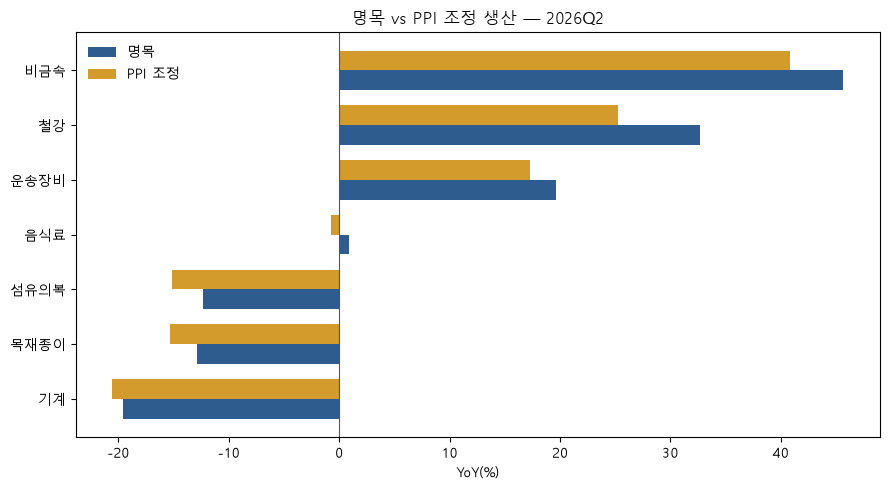

| industry | nominal_production_yoy | ppi_adjusted_production_yoy | ppi_mapping_grade |
| --- | --- | --- | --- |
| 기계 | -19.55 | -20.55 | A |
| 목재종이 | -12.90 | -15.29 | A |
| 섬유의복 | -12.32 | -15.17 | A |
| 음식료 | 0.87 | -0.78 | A |
| 운송장비 | 19.64 | 17.24 | A |
| 철강 | 32.65 | 25.28 | B |
| 비금속 | 45.67 | 40.86 | A |

In [4]:
p=evidence.loc[evidence.ppi_adjusted_production_yoy.notna(),['industry','nominal_production_yoy','ppi_adjusted_production_yoy','ppi_mapping_grade']].sort_values('nominal_production_yoy')
y=np.arange(len(p)); fig,ax=plt.subplots(figsize=(9,5)); ax.barh(y-.18,p.nominal_production_yoy,height=.36,label='명목',color='#2F5C8F')
ax.barh(y+.18,p.ppi_adjusted_production_yoy,height=.36,label='PPI 조정',color='#D39A2C'); ax.axvline(0,color='#555',lw=.8)
ax.set_yticks(y,p.industry); ax.set_xlabel('YoY(%)'); ax.set_title(f'명목 vs PPI 조정 생산 — {evidence.quarter.max()}'); ax.legend(frameon=False); plt.tight_layout(); plt.show()
show_table(p.round(2))

### 관찰 결과

- 최신 2026Q2에서 PPI 조정값이 있는 업종은 7개(grade A 6개, grade B 1개)다. grade C 2개·D 1개는 조정값을 계산하지 않는다.
- 음식료는 명목 +0.87%, PPI 조정 −0.78%로 방향이 갈린다. 기계(명목 −19.55%, 조정 −20.55%)와 목재종이(명목 −12.90%, 조정 −15.29%)는 두 기준 모두 감소 방향이다.

### 해석

- PPI는 명목 생산 변화가 가격효과만으로 설명되지 않는지 점검하는 보조 근거이지 실질 생산량 확정치가 아니다.

> 주의: 전국 PPI의 업종 매핑은 창원산단 실질생산량이 아니며, grade C/D는 조정값 자체를 계산하지 않는다.

## 4단계. EIS — 서로 다른 모집단의 고용 방향 교차확인

EIS는 범위가 다른 두 고용 통계를 나란히 읽기 위한 배경자료이며, KICOX의 정확성을 검증하는 정답 자료가 아니다.

### 왜 이걸 보나

KICOX는 산단 입주기업 고용이고 EIS는 창원시 전역 제조업 피보험자다. 두 계열이 같은 방향으로 움직이는지, 다르다면 언제 다른지 확인한다.

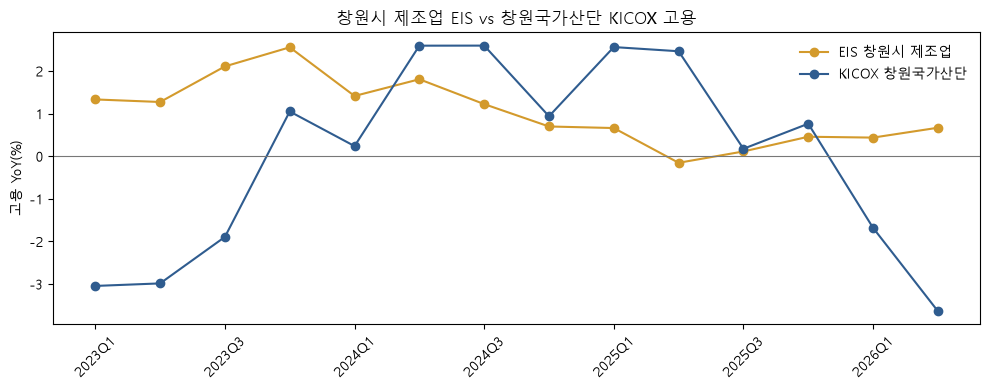

In [5]:
eis=pd.read_csv(config.EIS_PANEL_PATH,encoding='utf-8-sig').sort_values('quarter')
k=triage.groupby('quarter',as_index=False).employment.sum().sort_values('quarter'); k['kicox_yoy']=k.employment.pct_change(4)*100
e=eis.merge(k[['quarter','kicox_yoy']],on='quarter',how='left')
ax=e.plot(x='quarter',y=['eis_manufacturing_yoy_pct','kicox_yoy'],marker='o',figsize=(10,4),color=['#D39A2C','#2F5C8F'])
ax.axhline(0,color='#777',lw=.8); ax.set_ylabel('고용 YoY(%)'); ax.set_xlabel(''); ax.set_title('창원시 제조업 EIS vs 창원국가산단 KICOX 고용')
ax.legend(['EIS 창원시 제조업','KICOX 창원국가산단'],frameon=False); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

### 관찰 결과

- 비교 가능한 14개 분기 중 두 계열의 증감 방향이 같은 분기는 8개(57.1%)다.
- 최신 2026Q2는 EIS 창원시 제조업 YoY +0.67%인 반면 KICOX 창원국가산단 고용 YoY −3.64%로 방향이 다르다.

### 해석

- 방향이 같을 때는 지역 고용 맥락을 보강하고, 다를 때는 산단 고유 변화인지 확인할 질문을 만든다.

> 주의: EIS 제조업 총계로 KICOX 10개 업종 각각의 판정을 검증할 수 없다.

## 5단계. 최신 우선점검 2건의 외부근거

최신분기 추가확인은 0건이므로 아래는 우선점검 2개 업종을 중심으로 본다. 과거 추가확인 35건의 ELECTRE/SMAA 결과는 `03_triage.ipynb`에 보존했다.

### 왜 이걸 보나

우선점검 업종은 담당자가 바로 확인해야 하는 사례다. CORE·Triage 값과 외부근거를 같은 표에서 비교해, 06의 진단카드가 쓸 확인질문의 근거를 마련한다.

In [6]:
case_cols=['industry','quarter','stage','signal_profile','nominal_production_yoy','ppi_adjusted_production_yoy','trade_export_yoy','power_usage_yoy','bsi_region_business','bsi_industry_business','mfg_flow_job_openings','check_questions_context','handoff_review_functions']
cases=evidence.loc[evidence.stage.isin(['우선점검','추가확인']),case_cols]
show_table(cases)

| industry | quarter | stage | signal_profile | nominal_production_yoy | ppi_adjusted_production_yoy | trade_export_yoy | power_usage_yoy | bsi_region_business | bsi_industry_business | mfg_flow_job_openings | check_questions_context | handoff_review_functions |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 기계 | 2026Q2 | 우선점검 | 가동 위축 신호 · 실질생산 위축 신호(PPI 조정) | -19.55 | -20.55 | -38.10 | 0.75 | 74.67 | 76.84 | 513.00 | 가동률 하락이 일시적 생산조정인지 수주·수요 감소에 따른 것인지 확인할 필요가 있다. / 명목생산 변화에 가격효과가 포함되어 있으므로 실제 물량이 줄었는지 추가로 확인할 필요가 있다. / 확인된 품목 기준 수출이 함께 감소하고 있어, 외부수요 약화 가능성을 보려면 수출 감소가 특정 품목·기업에 집중되는지 추가 확인할 필요가 있다. / 창원시 제조업 전체에서 이직자 증가가 함께 관측되므로, 특정 사업장 조정 또는 노동이동과 관련된 것인지 추가 확인할 필요가 있다. / 가동률과 전력사용의 방향이 달라 업종 구성·설비 특성·자료범위(산단 vs 시 전체) 차이를 추가 확인할 필요가 있다. / 경남 제조업 업황 심리지수가 기준선(100)을 밑돌아, 업종 고유 요인인지 지역 전반의 경기 흐름인지 구분해 확인할 필요가 있다. / 같은 업종의 전국 업황 심리지수도 기준선을 밑돌아, 관측된 변화가 산단 고유 현상인지 전국 업종 흐름인지 확인할 필요가 있다. / 이 분기는 월별 원자료가 공표되지 않아 분기 내 지속 여부를 확인할 수 없다. 분기말 단일시점 값에만 의존한 판단임을 감안할 필요가 있다. / 연간보정 개정본을 사용한 구간이다. 이후 재개정 시 값이 달라질 수 있음을 확인할 필요가 있다. | 산업동향 · 기업지원 / 산업동향 / 고용지원 |
| 목재종이 | 2026Q2 | 우선점검 | 실질생산 위축 신호(PPI 조정) | -12.90 | -15.29 | — | 0.75 | 74.67 | 59.66 | 513.00 | 명목생산 변화에 가격효과가 포함되어 있으므로 실제 물량이 줄었는지 추가로 확인할 필요가 있다. / 창원시 제조업 전체에서 이직자 증가가 함께 관측되므로, 특정 사업장 조정 또는 노동이동과 관련된 것인지 추가 확인할 필요가 있다. / 경남 제조업 업황 심리지수가 기준선(100)을 밑돌아, 업종 고유 요인인지 지역 전반의 경기 흐름인지 구분해 확인할 필요가 있다. / 같은 업종의 전국 업황 심리지수도 기준선을 밑돌아, 관측된 변화가 산단 고유 현상인지 전국 업종 흐름인지 확인할 필요가 있다. / 이 분기는 월별 원자료가 공표되지 않아 분기 내 지속 여부를 확인할 수 없다. 분기말 단일시점 값에만 의존한 판단임을 감안할 필요가 있다. / 연간보정 개정본을 사용한 구간이다. 이후 재개정 시 값이 달라질 수 있음을 확인할 필요가 있다. | 산업동향 / 고용지원 |

### 관찰 결과

- <b>기계</b> — 우선점검. 명목 생산 YoY −19.55%, PPI 조정 −20.55%(grade A), 수출 YoY −38.10%(grade B), 경남 BSI 74.67, 전국 기계업종 BSI 76.84로 모두 기준선(100) 아래다.
- <b>목재종이</b> — 우선점검. 명목 생산 YoY −12.90%, PPI 조정 −15.29%(grade A). 수출 매핑은 없고, 경남 BSI 74.67, 전국 BSI 59.66이다.
- 두 업종 모두 전력사용량은 창원시 전역 제조업 총계(YoY +0.75%)만 있어 업종별 전력과 개념이 다르다.

### 해석

- 기계는 생산·수출·심리지수가 함께 낮은 방향으로 관측된다. 목재종이는 생산 관련 신호만 확인되고 수출은 비교 자료가 없다.

> 주의: 심리지수·전력은 창원시·경남·전국 단위이며 산단 개별 업종의 확정치가 아니다.

## 6단계. 불일치와 미확인의 처리

- 일치 — "CORE와 방향이 함께 관측된다"까지 기록하고, 원인이 같다고 단정하지 않는다.
- 불일치 — 어느 자료가 틀렸다고 판정하지 않고 공간·업종·빈도·가격/물량 차이를 확인 질문으로 남긴다.
- 미확인 — 최신분기 부재, 매핑 불충분, 단면자료이면 `unavailable / insufficient`로 남긴다.
- 어떤 경우에도 외부자료가 Triage stage를 자동으로 바꾸지 않는다.

# 정리

## 확인한 것

- 자료 역할 15종을 CORE 2·VALIDATION 2·CONTEXT 9·EXCLUDE 2로 구분했고, 최신 10개 업종의 외부근거가 Triage 최신분기 stage와 같은 구성임을 확인했다.
- 최신 우선점검 2건(기계, 목재종이)은 PPI 조정 생산도 감소 방향이며, 기계는 수출·심리지수까지 같은 방향이다.
- EIS와 KICOX 고용은 14개 비교 분기 중 8개(57.1%)만 방향이 같고, 최신분기는 방향이 다르다.

## 말할 수 없는 것

- 명목·PPI 조정 생산이 함께 감소한다고 해서 기업별 원인(수주·자동화·외주화·휴업·투자·이직)을 확정할 수 없다.
- KEPCO 법정동×KSIC, 고용24는 현재 자료 범위상 이번 분기 판정 근거로 쓸 수 없다.

## 다음 단계

외부근거도 기업별 원인을 확정하지 못하므로, 다음 단계에서 담당자가 확인할 질문과 기존 지원기능으로의 인계경로를 명시해야 한다.

다음: `06_final_results.ipynb`